In [ ]:
import os
import torch
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm

# reminder to self, run this with the full dataset of tensors

REAL_FOLDER = './data/processed_data/real'
FAKE_FOLDER = './data/processed_data/fake'

def get_signals_for_graphing(folder):
    files = [f for f in os.listdir(folder) if f.endswith('.pt')]
    
    all_fft = []
    all_prnu = []
    all_jitter = []
    all_audio = []

    for f in tqdm(files, desc=f"Processing {os.path.basename(folder)}"):
        try:
            data = torch.load(os.path.join(folder, f), map_location='cpu', weights_only=False)
            
            # 1. Spatial Frequency (FFT)
            if 'fft' in data:
                fft_2d = data['fft'].squeeze().to(torch.float32).numpy()
                y, x = np.indices(fft_2d.shape)
                center = np.array([(x.max()-x.min())/2.0, (y.max()-y.min())/2.0])
                r = np.sqrt((x - center[0])**2 + (y - center[1])**2).astype(int)
                tbin = np.bincount(r.ravel(), fft_2d.ravel())
                nr = np.bincount(r.ravel())
                all_fft.append(tbin / (nr + 1e-8))

            # 2. PRNU Energy (Raw Variance)
            if 'prnu' in data:
                all_prnu.append(np.var(data['prnu'].squeeze().to(torch.float32).numpy()))

            # 3. Temporal Jitter (Keeping the full sequence)
            if 'rgb_batch' in data:
                rgb = data['rgb_batch'].to(torch.float32).numpy() / 255.0
                jitter_seq = np.mean(np.abs(rgb[1:] - rgb[:-1]), axis=(1, 2, 3))
                all_jitter.append(jitter_seq)

            # 4. Audio Centroid
            if 'audio' in data:
                spec = data['audio'].squeeze().to(torch.float32).numpy()
                freq_bins = np.arange(spec.shape[0])
                centroid = np.sum(spec * freq_bins[:, np.newaxis], axis=0) / (np.sum(spec, axis=0) + 1e-8)
                all_audio.append(np.mean(centroid))
                
        except Exception:
            continue
            
    # Align jitter sequences in case some videos dropped a frame
    min_frames = min(len(j) for j in all_jitter) if all_jitter else 0
    aligned_jitter = [j[:min_frames] for j in all_jitter]

    return {
        'fft_mean': np.mean(all_fft, axis=0) if all_fft else [],
        'prnu': all_prnu,
        'jitter_mean': np.mean(aligned_jitter, axis=0) if aligned_jitter else [],
        'jitter_std': np.std(aligned_jitter, axis=0) if aligned_jitter else [],
        'audio': all_audio
    }

Extracting tensors...


Processing fake: 100%|██████████| 23/23 [00:00<00:00, 38.57it/s]


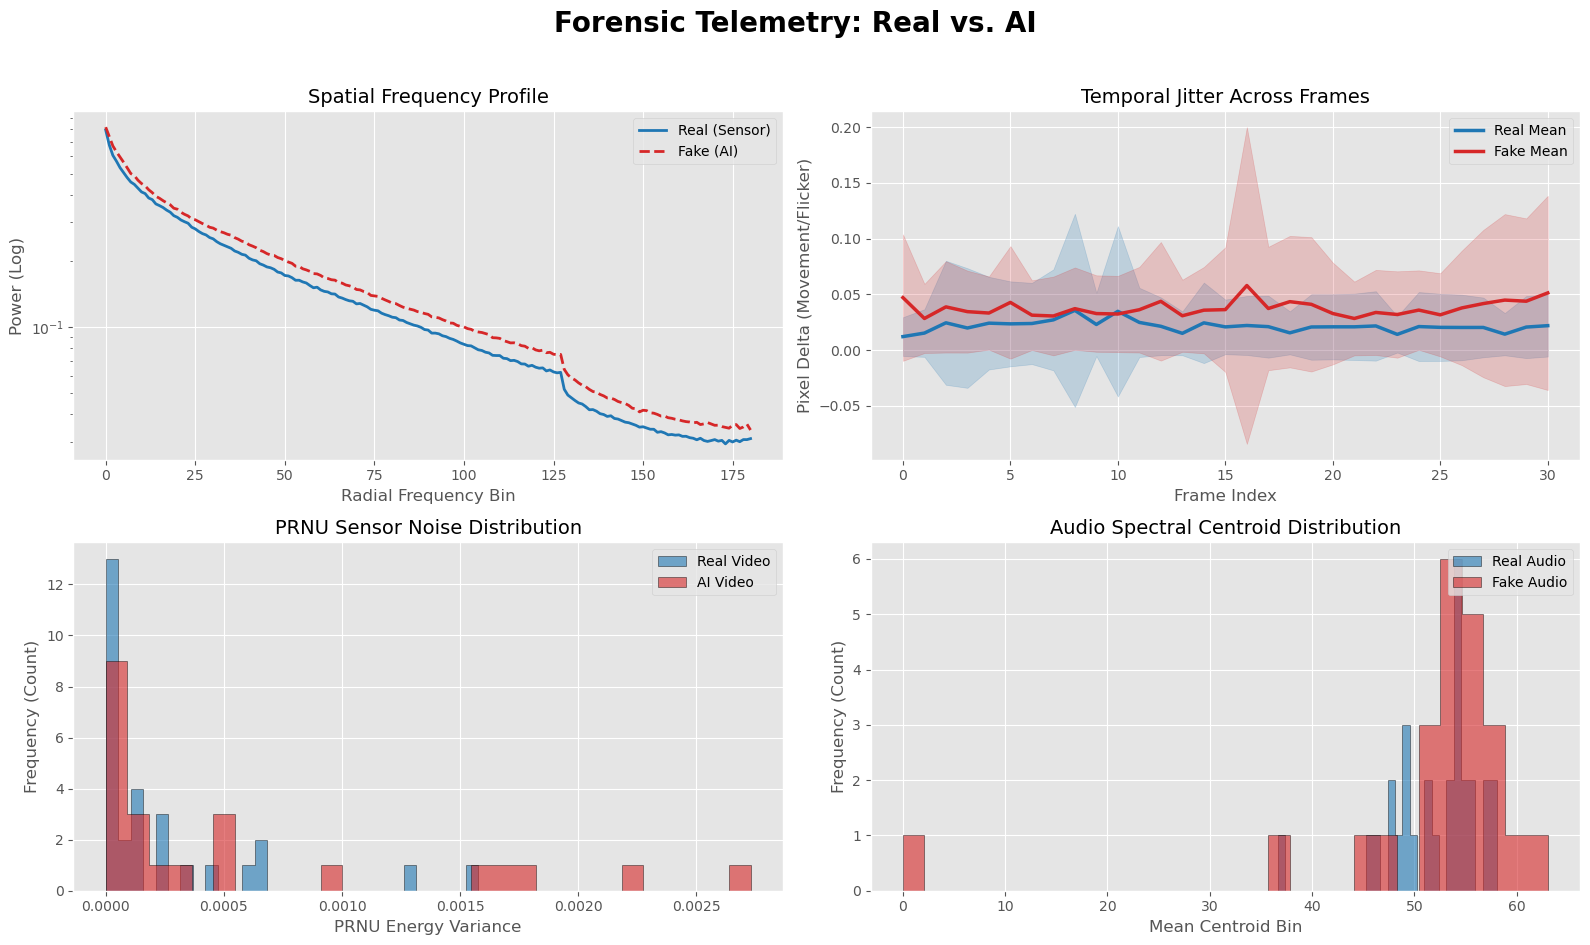

In [ ]:
print("Extracting tensors...")
real_data = get_signals_for_graphing(REAL_FOLDER)
fake_data = get_signals_for_graphing(FAKE_FOLDER)

plt.style.use('ggplot')
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle("Forensic Telemetry: Real vs. AI", fontsize=20, fontweight='bold', y=0.97)

# Colors
C_REAL = '#1f77b4' # Deep Blue
C_FAKE = '#d62728' # Deep Red

# Graph 1: Spatial FFT 
ax = axes[0, 0]
ax.plot(real_data['fft_mean'], label='Real (Sensor)', color=C_REAL, linewidth=2)
ax.plot(fake_data['fft_mean'], label='Fake (AI)', color=C_FAKE, linewidth=2, linestyle='--')
ax.set_title("Spatial Frequency Profile", fontsize=14)
ax.set_yscale('log')
ax.set_ylabel("Power (Log)")
ax.set_xlabel("Radial Frequency Bin")
ax.legend(loc='upper right')

#  Graph 2: Temporal Jitter 
ax = axes[0, 1]
x_frames = np.arange(len(real_data['jitter_mean']))
# Plot mean lines
ax.plot(x_frames, real_data['jitter_mean'], label='Real Mean', color=C_REAL, linewidth=2.5)
ax.plot(x_frames, fake_data['jitter_mean'], label='Fake Mean', color=C_FAKE, linewidth=2.5)
# Fill variance (opacity)
ax.fill_between(x_frames, real_data['jitter_mean'] - real_data['jitter_std'], 
                real_data['jitter_mean'] + real_data['jitter_std'], color=C_REAL, alpha=0.2)
ax.fill_between(x_frames, fake_data['jitter_mean'] - fake_data['jitter_std'], 
                fake_data['jitter_mean'] + fake_data['jitter_std'], color=C_FAKE, alpha=0.2)
ax.set_title("Temporal Jitter Across Frames", fontsize=14)
ax.set_ylabel("Pixel Delta (Movement/Flicker)")
ax.set_xlabel("Frame Index")
ax.legend(loc='upper right')

#  Graph 3: PRNU Noise Energy 
ax = axes[1, 0]
ax.hist(real_data['prnu'], bins=30, alpha=0.6, label='Real Video', color=C_REAL, edgecolor='black', histtype='stepfilled')
ax.hist(fake_data['prnu'], bins=30, alpha=0.6, label='AI Video', color=C_FAKE, edgecolor='black', histtype='stepfilled')
ax.set_title("PRNU Sensor Noise Distribution", fontsize=14)
ax.set_ylabel("Frequency (Count)")
ax.set_xlabel("PRNU Energy Variance")
ax.legend(loc='upper right')

#  Graph 4: Audio Centroid 
ax = axes[1, 1]
ax.hist(real_data['audio'], bins=30, alpha=0.6, label='Real Audio', color=C_REAL, edgecolor='black', histtype='stepfilled')
ax.hist(fake_data['audio'], bins=30, alpha=0.6, label='Fake Audio', color=C_FAKE, edgecolor='black', histtype='stepfilled')
ax.set_title("Audio Spectral Centroid Distribution", fontsize=14)
ax.set_ylabel("Frequency (Count)")
ax.set_xlabel("Mean Centroid Bin")
ax.legend(loc='upper right')

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()